In [92]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import pandas as pd
import requests

In [93]:
print(np.__version__)
#print(plt.__version__)
print(sk.__version__)

2.5.2
1.9.0


In [94]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [95]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [96]:
df.shape

(19402, 4)

In [97]:
df.dtypes

entity                     str
code                       str
year                     int64
fertility_rate_hist    float64
dtype: object

In [98]:
mexico = df[df["entity"] == "Mexico"]
mexico.head(5)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [99]:
japon = df[df["entity"] == "Japan"]
japon.head()


,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225


In [100]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()



In [101]:
prom_mexico =np.mean(tasa_mexico)
std_mexico =np.std(tasa_mexico)
min_mexico =np.min(tasa_mexico)
max_mexico =np.max(tasa_mexico)

print(min_mexico)
print(max_mexico)

prom_japon =np.mean(tasa_japon)
std_japon=np.std(tasa_japon)
min_japon=np.min(tasa_japon)
max_japon=np.max(tasa_japon)

1.91
6.833


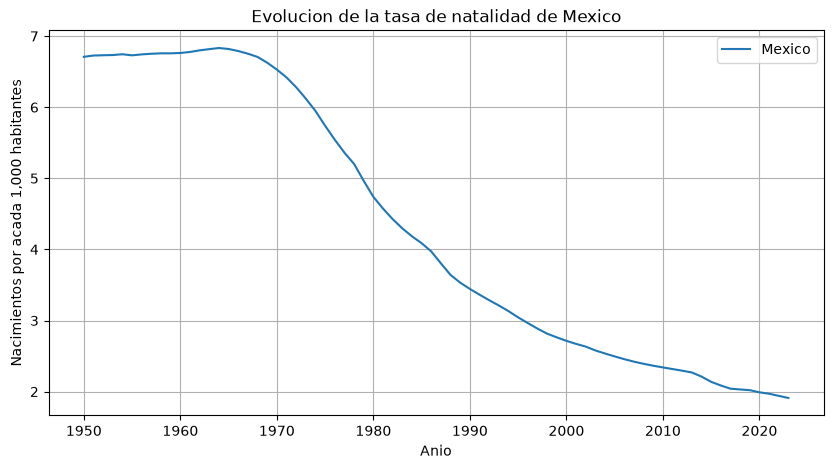

In [102]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)
plt.title("Evolucion de la tasa de natalidad de Mexico")
plt.xlabel("Anio")
plt.ylabel("Nacimientos por acada 1,000 habitantes")
plt.grid(True)
plt.legend()

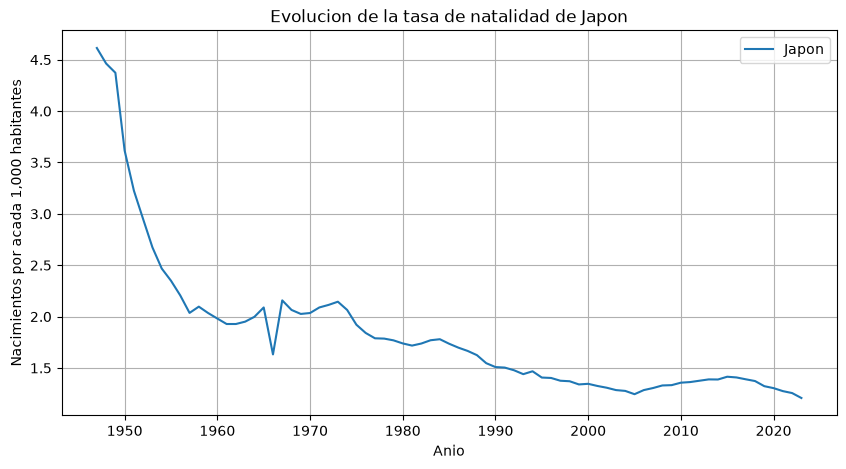

In [103]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japon"
)
plt.title("Evolucion de la tasa de natalidad de Japon")
plt.xlabel("Anio")
plt.ylabel("Nacimientos por acada 1,000 habitantes")
plt.grid(True)
plt.legend()

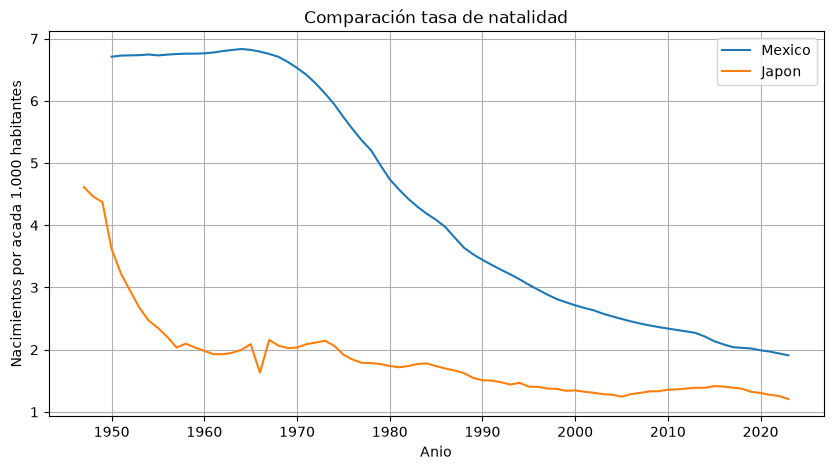

In [104]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label="Japon"
)
plt.title("Comparación tasa de natalidad")
plt.xlabel("Anio")
plt.ylabel("Nacimientos por acada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [105]:
#Sacar minimo de mexico y traer los de japon que sean iguales o mayores. FILTRO BOOLEANO
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
print(mascara_coincidencia_anios)

[False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


In [ ]:
anios_japon = anios_japon[mascara_coincidencia_anios]


In [111]:
print(anios_japon)


[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023]


In [114]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]


In [115]:
tasa_japon.shape

(74,)

In [116]:
diferencia = tasa_mexico - tasa_japon
diferencia

array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723, 4.782, 4.849, 4.872, 4.866, 4.835, 4.73 , 5.158, 4.595,
       4.642, 4.6  , 4.494, 4.33 , 4.167, 3.976, 3.882, 3.818, 3.702,
       3.572, 3.416, 3.195, 3.   , 2.856, 2.687, 2.526, 2.404, 2.351,
       2.273, 2.137, 2.015, 1.985, 1.935, 1.859, 1.807, 1.771, 1.664,
       1.637, 1.561, 1.51 , 1.444, 1.423, 1.368, 1.346, 1.325, 1.294,
       1.259, 1.25 , 1.171, 1.116, 1.061, 1.031, 0.983, 0.954, 0.918,
       0.88 , 0.823, 0.722, 0.678, 0.651, 0.657, 0.697, 0.686, 0.695,
       0.684, 0.702])

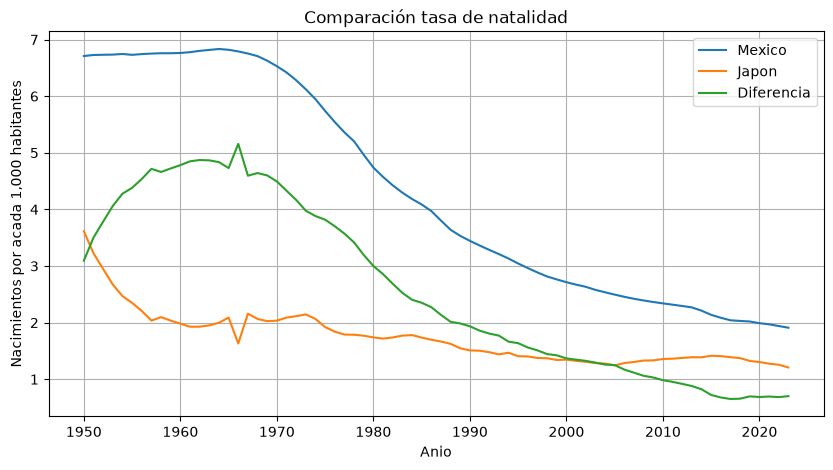

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label="Japon"
)

plt.plot(
    anios_mexico, #Eje x
    diferencia, #Eje y
    label="Diferencia"
)

plt.title("Comparación tasa de natalidad")
plt.xlabel("Anio")
plt.ylabel("Nacimientos por acada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [120]:
# Comparación mexico / brazil
brazil = df[df["entity"] == "Brazil"]
brazil.head(5)

,entity,code,year,fertility_rate_hist
2371,Brazil,BRA,1950,6.122
2372,Brazil,BRA,1951,6.115
2373,Brazil,BRA,1952,6.102
2374,Brazil,BRA,1953,6.093
2375,Brazil,BRA,1954,6.087


In [121]:
anios_brazil = brazil["year"].to_numpy()
tasa_brazil = brazil["fertility_rate_hist"].to_numpy()

In [126]:
diferencia_mexico_brazil  = tasa_mexico - tasa_brazil

In [122]:
brazil.shape

(74, 4)

In [123]:
mexico.shape

(74, 4)

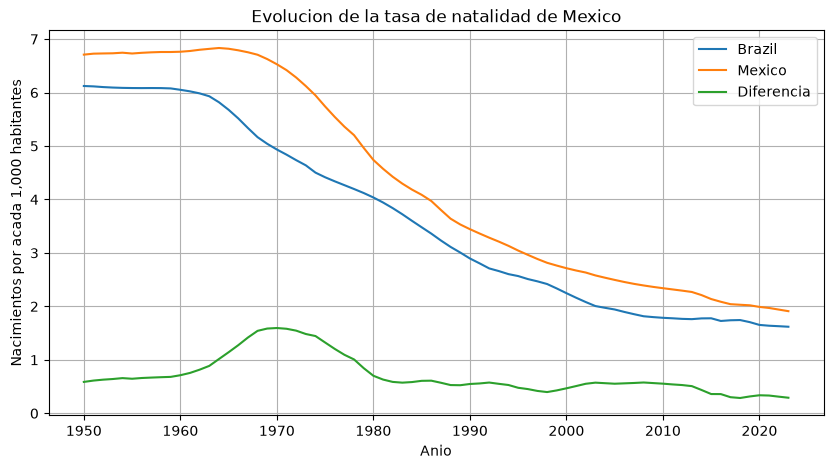

In [127]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_brazil,
    tasa_brazil,
    label="Brazil"
)
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)
plt.plot(
    anios_mexico,
    diferencia_mexico_brazil,
    label="Diferencia"
)
plt.title("Evolucion de la tasa de natalidad de Mexico")
plt.xlabel("Anio")
plt.ylabel("Nacimientos por acada 1,000 habitantes")
plt.grid(True)
plt.legend()